# Training and test set generation

In [1]:
import pathlib

from collections import defaultdict

import numpy as np
import pandas as pd

In [2]:
np.random.seed(42)

In [3]:
DATASETS = ["atleaf", "lit", "pmi"]
DATASETS_ALL = ["atleaf", "lit", "pmi", "atleaf_lit", "atleaf_lit-g",  "atleaf_lit-a", "atleaf_lit_pmi",  "atleaf_lit_pmi-g",  "atleaf_lit_pmi-a"]

## Read genome information

In [4]:
genome_info = pd.read_csv("../data/raw/phylogeny/genome_info_parsed.tsv", index_col=0, sep="\t")
genome_info

,dataset,Phylum,Class
genomeID,,,
Chitinophaga_sp._OK723_2757320416,pmi,Bacteroidota,Bacteroidia
Chitinophaga_sp._YR627_2693429788,pmi,Bacteroidota,Bacteroidia
Chitinophaga_sp._CF418_2609459644,pmi,Bacteroidota,Bacteroidia
Chitinophaga_sp._CF118_2687453677,pmi,Bacteroidota,Bacteroidia
Chitinophaga_sp._YR573_2690315653,pmi,Bacteroidota,Bacteroidia
...,...,...,...
Pseudomonas_sp._GV105_2738541303,pmi,Proteobacteria,Gammaproteobacteria
Pseudomonas_sp._GV058_2738541282,pmi,Proteobacteria,Gammaproteobacteria
Pseudomonas_sp._GV062_2757320437,pmi,Proteobacteria,Gammaproteobacteria


In [5]:
set(genome_info["Class"])

{'Actinomycetia',
 'Alicyclobacillia',
 'Alphaproteobacteria',
 'Bacilli',
 'Bacteroidia',
 'Campylobacteria',
 'Gammaproteobacteria',
 'missing'}

## Determine the common phenotypes

In [6]:
phenotypes_folder_base = pathlib.Path("../data/processed/phenotypes")
phenotypes_folder = dict()
for dataset in DATASETS:
    phenotypes_folder[dataset] = phenotypes_folder_base / dataset
phenotypes_files = dict()
for dataset in DATASETS:
    phenotypes_files[dataset] = [f.stem for f in phenotypes_folder[dataset].glob("*.tsv")]

In [7]:
# Get set of all common phenotypes
common_phenotype_names = sorted(set(phenotypes_files["atleaf"]) & set(phenotypes_files["lit"]) & set(phenotypes_files["pmi"]))
common_phenotype_names, len(common_phenotype_names)

(['Alanine',
  'Arginine',
  'Cellobiose',
  'Fructose',
  'Galactose',
  'Galacturonic-Acid',
  'Glucose',
  'Glycerol',
  'Histidine',
  'Maltose',
  'Mannitol',
  'Mannose',
  'Serine',
  'Sucrose',
  'Trehalose',
  'm-Inositol'],
 16)

In [8]:
def get_phenotype_file(path: pathlib.Path, name: str) -> pathlib.Path:
    return path / f"{name}.tsv"

## Read phenotypes and combine datasets

In [9]:
phenotypes_full = defaultdict(dict)
for phenotype_name in common_phenotype_names:
    for dataset in DATASETS:
        phenotype_file = get_phenotype_file(phenotypes_folder[dataset], phenotype_name)
        phenotypes_full[dataset][phenotype_name] = pd.read_csv(phenotype_file, sep="\t", index_col=0, dtype={"genomeID": str}).dropna().astype(np.int8)
    phenotypes_full["atleaf_lit"][phenotype_name] = pd.concat([phenotypes_full["atleaf"][phenotype_name], phenotypes_full["lit"][phenotype_name]])
    phenotypes_full["atleaf_lit-g"][phenotype_name] = phenotypes_full["atleaf_lit"][phenotype_name].drop(genome_info[genome_info["Class"] == "Gammaproteobacteria"].index, errors="ignore")
    phenotypes_full["atleaf_lit-a"][phenotype_name] = phenotypes_full["atleaf_lit"][phenotype_name].drop(genome_info[genome_info["Class"] == "Alphaproteobacteria"].index, errors="ignore")
    phenotypes_full["atleaf_lit_pmi"][phenotype_name] = pd.concat([phenotypes_full["atleaf"][phenotype_name], phenotypes_full["lit"][phenotype_name], phenotypes_full["pmi"][phenotype_name]])
    phenotypes_full["atleaf_lit_pmi-g"][phenotype_name] = phenotypes_full["atleaf_lit_pmi"][phenotype_name].drop(genome_info[genome_info["Class"] == "Gammaproteobacteria"].index, errors="ignore")
    phenotypes_full["atleaf_lit_pmi-a"][phenotype_name] = phenotypes_full["atleaf_lit_pmi"][phenotype_name].drop(genome_info[genome_info["Class"] == "Alphaproteobacteria"].index, errors="ignore")

In [10]:
phenotypes_full["atleaf"]["Alanine"]

,Alanine
genomeID,
GCF_001421155.1,1
GCF_001421165.1,0
GCF_001421245.1,1
GCF_001421275.1,1
GCF_001421285.1,1
...,...
GCF_920984695.1,0
GCF_920984705.1,0
GCF_920984725.1,1


In [11]:
phenotypes_full["atleaf_lit_pmi"]["Alanine"]

,Alanine
genomeID,
GCF_001421155.1,1
GCF_001421165.1,0
GCF_001421245.1,1
GCF_001421275.1,1
GCF_001421285.1,1
...,...
Pseudomonas_sp._GM67_2511231019,1
Pseudomonas_sp._GM79_2511231022,1
Pseudomonas_sp._GM102_2511231004,1


## Create the full training sets for each phenotype (+ eval set)

1. AT Leaf
2. Lit
3. AT Leaf + Lit

3 X matrices (without feature selection, but correlation and variance filtered)

Evaluation set is created by uniformly sampling 10-20% of all the data (AT Leaf + Lit) for a phenotype

In [12]:
features_folder_base = pathlib.Path("../data/processed/features_reduced")
features_folder = dict()
for dataset in DATASETS:
    features_folder[dataset] = features_folder_base / dataset
features_files = dict()
for dataset in DATASETS:
    features_files[dataset] = features_folder[dataset] / "kofam/kofam.tsv"

In [13]:
features_full = dict()
for dataset in DATASETS:
    features_full[dataset] = pd.read_csv(features_files[dataset], sep="\t", index_col=0, dtype={"genomeID": str}).astype(np.int8)
features_full["atleaf_lit"] = pd.concat([features_full["atleaf"], features_full["lit"]], axis=0, join="outer").fillna(0).astype(np.int8)
features_full["atleaf_lit-g"] = features_full["atleaf_lit"].drop(genome_info[genome_info["Class"] == "Gammaproteobacteria"].index, errors="ignore")
features_full["atleaf_lit-a"] = features_full["atleaf_lit"].drop(genome_info[genome_info["Class"] == "Alphaproteobacteria"].index, errors="ignore")
features_full["atleaf_lit_pmi"] = pd.concat([features_full["atleaf"], features_full["lit"], features_full["pmi"]], axis=0, join="outer").fillna(0).astype(np.int8)
features_full["atleaf_lit_pmi-g"] = features_full["atleaf_lit_pmi"].drop(genome_info[genome_info["Class"] == "Gammaproteobacteria"].index, errors="ignore")
features_full["atleaf_lit_pmi-a"] = features_full["atleaf_lit_pmi"].drop(genome_info[genome_info["Class"] == "Alphaproteobacteria"].index, errors="ignore")

In [14]:
[f.shape for f in features_full.values()]

[(206, 3925),
 (362, 5345),
 (55, 1935),
 (568, 5608),
 (306, 5608),
 (477, 5608),
 (623, 5656),
 (336, 5656),
 (503, 5656)]

In [15]:
# Create feature matrix for each phenotype
features = defaultdict(dict)
phenotypes = defaultdict(dict)
for phenotype_name in common_phenotype_names:
    for dataset in DATASETS_ALL:
        phenotype_index = phenotypes_full[dataset][phenotype_name].index
        feature_index = features_full[dataset].index
        common_index = feature_index.intersection(phenotype_index)
        phenotype_data = phenotypes_full[dataset][phenotype_name].loc[common_index]
        feature_data = features_full[dataset].loc[common_index]
        phenotypes[dataset][phenotype_name] = phenotype_data
        features[dataset][phenotype_name] =  feature_data

In [16]:
features["lit"]["Alanine"]

,K09681,K11921,K04761,K00241,K00239,K00240,K22310,K03701,K23107,K01179,...,K21285,K03489,K07784,K21252,K05789,K07307,K13629,K07796,K23254,K18673
genomeID,,,,,,,,,,,,,,,,,,,,,
34072.40,0,0,1,1,1,1,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
1663.228,0,0,0,1,1,1,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
34073.57,0,1,1,1,1,1,1,1,1,0,...,0,0,0,0,0,0,0,0,0,0
1219046.3,0,0,1,0,1,1,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
1217653.3,0,0,1,0,1,1,1,1,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1178537.3,1,0,0,1,1,1,0,1,0,1,...,1,0,0,0,0,0,0,0,0,1
1663.203,0,0,0,1,1,0,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0
242606.43,0,1,1,1,1,1,0,1,1,0,...,0,0,0,0,0,0,0,0,0,0


In [17]:
features["atleaf_lit_pmi"]["Alanine"]

,K09681,K11921,K00241,K22310,K23107,K01179,K06400,K07492,K08166,K02529,...,K18937,K01217,K17238,K20252,K11176,K13642,K16553,K16563,K24290,K20249
genomeID,,,,,,,,,,,,,,,,,,,,,
GCF_001424285.1,0,0,1,0,1,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
GCF_001423985.1,0,0,1,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
GCF_001421585.1,0,0,1,0,0,1,0,1,0,1,...,0,0,0,0,0,0,0,0,0,0
GCF_920984665.1,0,0,1,0,0,1,1,0,0,1,...,0,0,0,0,0,0,0,0,0,0
GCF_001421415.1,0,0,1,0,1,0,1,1,0,1,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
Agrobacterium_rhizogenes_OV677_2585427608,0,0,1,0,1,1,0,0,1,1,...,0,0,0,0,0,0,1,1,1,0
Pseudomonas_sp._GM55_2511231017,0,1,0,0,0,0,0,0,0,1,...,0,0,0,0,0,0,0,0,0,0
Agrobacterium_rhizogenes_YR147_2582581315,0,0,1,0,1,1,1,0,0,1,...,0,0,0,0,0,0,0,1,0,0


### Create evaluation set

1. Read tree data
2. Create distance matrix
3. Subset distance matrix for each phenotype (for all datasets - AT Leaf and Lit)
4. Perform hierarchical clustering (agglomerative) on the distance matrix
5. Select n_clusters=10-20% of the data
6. For every feature matrix remove the indices in the eval set to create the training set

In [18]:
from ete3 import Tree

In [19]:
tree_file = "../data/raw/phylogeny/v2_all_combined_trimmed_tree-labels.newick"
tree = Tree(tree_file, format=1)
tree

Tree node '' (0x7f1124ed771)

In [20]:
# Suffixes to remove: ".fna", ".RAST", ".genome"
for leaf in tree.iter_leaves():
    leaf.name = leaf.name.strip().removesuffix(".fna").removesuffix(".RAST").removesuffix(".genome")

In [21]:
def calculate_leafdist(tree):
    leaves = tree.get_leaf_names()
    distance_matrix = np.zeros((len(leaves), len(leaves)))
    for i, leaf1 in enumerate(leaves):
        for j, leaf2 in enumerate(leaves):
            if leaf1 == leaf2:
                distance_matrix[i, j] = 0
                continue
            distance = tree.get_distance(leaf1, leaf2)
            distance_matrix[i, j] = distance
    return pd.DataFrame(distance_matrix, index=leaves, columns=leaves)

In [22]:
distance_matrix_file = pathlib.Path("../data/processed/distance_matrix.tsv")

In [23]:
if distance_matrix_file.exists():
    distance_matrix = pd.read_csv(distance_matrix_file, sep="\t", index_col=0)
else:
    distance_matrix = calculate_leafdist(tree)
    distance_matrix.to_csv(distance_matrix_file, sep="\t", index=True)
distance_matrix

,Chitinophaga_sp._OK723_2757320416,Chitinophaga_sp._YR573_2690315653,Chitinophaga_sp._CF118_2687453677,Chitinophaga_sp._CF418_2609459644,Chitinophaga_sp._YR627_2693429788,Niastella_sp._CF465_2738541278,Filimonas_sp._YR581_2757320532,FW305-C-49,FW305-C-271,FW305-C-272,...,Pseudomonas_sp._PDC86_2687453791,GW460-12,MPR-R2A7,MPR-R2A5,MPR-R2A4,MPR-R2A3,MPR-LB5,MPR-R2A6,MPR-LB3,MPR-ANB1
Chitinophaga_sp._OK723_2757320416,0.00000,0.19769,0.19788,0.18791,0.20835,0.41594,0.49327,0.43515,0.44666,0.44666,...,1.73420,1.73420,1.73420,1.73420,1.73420,1.73420,1.73420,1.73420,1.73420,1.73420
Chitinophaga_sp._YR573_2690315653,0.19769,0.00000,0.04833,0.11332,0.13376,0.43953,0.51686,0.45874,0.47025,0.47025,...,1.75779,1.75779,1.75779,1.75779,1.75779,1.75779,1.75779,1.75779,1.75779,1.75779
Chitinophaga_sp._CF118_2687453677,0.19788,0.04833,0.00000,0.11351,0.13395,0.43972,0.51705,0.45893,0.47044,0.47044,...,1.75798,1.75798,1.75798,1.75798,1.75798,1.75798,1.75798,1.75798,1.75798,1.75798
Chitinophaga_sp._CF418_2609459644,0.18791,0.11332,0.11351,0.00000,0.07222,0.42975,0.50708,0.44896,0.46047,0.46047,...,1.74801,1.74801,1.74801,1.74801,1.74801,1.74801,1.74801,1.74801,1.74801,1.74801
Chitinophaga_sp._YR627_2693429788,0.20835,0.13376,0.13395,0.07222,0.00000,0.45019,0.52752,0.46940,0.48091,0.48091,...,1.76845,1.76845,1.76845,1.76845,1.76845,1.76845,1.76845,1.76845,1.76845,1.76845
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
MPR-R2A3,1.73420,1.75779,1.75798,1.74801,1.76845,1.77428,1.85161,1.79349,1.80500,1.80500,...,0.00220,0.00110,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
MPR-LB5,1.73420,1.75779,1.75798,1.74801,1.76845,1.77428,1.85161,1.79349,1.80500,1.80500,...,0.00220,0.00110,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
MPR-R2A6,1.73420,1.75779,1.75798,1.74801,1.76845,1.77428,1.85161,1.79349,1.80500,1.80500,...,0.00220,0.00110,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000
MPR-LB3,1.73420,1.75779,1.75798,1.74801,1.76845,1.77428,1.85161,1.79349,1.80500,1.80500,...,0.00220,0.00110,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000,0.00000


In [24]:
from sklearn.cluster import AgglomerativeClustering

In [25]:
# evaluation datasets
eval_features = defaultdict(dict)
eval_phenotypes = defaultdict(dict)
for dataset in DATASETS_ALL:
    for phenotype_name in common_phenotype_names:
        feature_index = features[dataset][phenotype_name].index
        index = feature_index.intersection(distance_matrix.index)
        distance_matrix_subset = distance_matrix.loc[index, index]
        n_clusters = int(len(index) * 0.1)
        clustering = AgglomerativeClustering(n_clusters=n_clusters, metric="precomputed", linkage="average")
        clustering.fit(distance_matrix_subset)
        labels = clustering.labels_
        unique_labels = np.unique(labels)
        sampled_elements = [np.random.choice(index[labels == label], 1)[0] for label in unique_labels]
        eval_features[dataset][phenotype_name] = features[dataset][phenotype_name].loc[sampled_elements, :]
        eval_phenotypes[dataset][phenotype_name] = phenotypes[dataset][phenotype_name].loc[sampled_elements]

In [26]:
from sklearn.feature_selection import chi2, SelectKBest

In [27]:
# Training data
train_features = defaultdict(dict)
train_phenotypes = defaultdict(dict)
for dataset in DATASETS_ALL:
    for phenotype_name in common_phenotype_names:
        eval_index = eval_features[dataset][phenotype_name].index
        feature_data_full = features[dataset][phenotype_name].drop(index=eval_index)
        phenotype_data = phenotypes[dataset][phenotype_name].drop(index=eval_index)
        kbest = SelectKBest(chi2, k=1000)
        kbest_features = kbest.fit_transform(feature_data_full, phenotype_data)
        cols = feature_data_full.columns[kbest.get_support()]
        index = feature_data_full.index
        feature_data = pd.DataFrame(kbest_features, index=index, columns=cols)
        train_phenotypes[dataset][phenotype_name] = phenotype_data
        train_features[dataset][phenotype_name] =  feature_data
        # update eval_features
        eval_features[dataset][phenotype_name] = eval_features[dataset][phenotype_name][cols]

## Create the test sets (X & y)

1. PMI dataset
2. Lit (full)
3. Leaf (full)
4. Out-of-clade - Gammaproteobacteria (to test AT Leaf) and Alphaproteobacteria (to test Lit)
5. In-clade - Actinomycetia + Bacteroidia + Bacili
6. Uniform sampling (50 clusters)

y vectors, for phenotypes that are in-common between all 3 datasets
Make sure to note down the class counts for these

In [28]:
DATASETS_TEST = ["atleaf", "lit", "pmi", "out_gamma", "out_alpha", "in_abb", "uniform"]

In [29]:
test_features = defaultdict(dict)
test_phenotypes = defaultdict(dict)

### Mapping training and test sets

In [30]:
train_test_map = {
    "atleaf": ["in_abb", "lit", "out_gamma", "pmi", "uniform"],
    "lit": ["atleaf", "in_abb", "out_alpha", "pmi", "uniform"],
    "atleaf_lit": ["in_abb", "pmi"],
    "atleaf_lit-g": ["out_gamma", "pmi"],
    "atleaf_lit-a": ["out_alpha", "pmi"],
    "atleaf_lit_pmi": [],
    "atleaf_lit_pmi-g": ["out_gamma"],
    "atleaf_lit_pmi-a": ["out_alpha"],
}

In [31]:
N_REPS = 5
FRAC = 0.2

In [32]:
for dataset in ["atleaf", "lit", "pmi"]:
    for phenotype_name in common_phenotype_names:
        # NOTE: Avoiding adding the eval set to the test set
        n_samples = int(features[dataset][phenotype_name].shape[0] * FRAC)
        test_features[dataset][phenotype_name] = []
        test_phenotypes[dataset][phenotype_name] = []
        for _ in range(N_REPS):
            test_index = np.random.choice(features[dataset][phenotype_name].index, n_samples, replace=False)
            test_features[dataset][phenotype_name].append(features[dataset][phenotype_name].loc[test_index, :])
            test_phenotypes[dataset][phenotype_name].append(phenotypes[dataset][phenotype_name].loc[test_index])

In [33]:
for dataset in ["out_gamma", "out_alpha", "in_abb"]:
    for phenotype_name in common_phenotype_names:
        X = features["atleaf_lit_pmi"][phenotype_name]
        y = phenotypes["atleaf_lit_pmi"][phenotype_name]
        if dataset == "out_gamma":
            index = genome_info[genome_info["Class"] == "Gammaproteobacteria"].index
        elif dataset == "out_alpha":
            index = genome_info[genome_info["Class"] == "Alphaproteobacteria"].index
        elif dataset == "in_abb":
            index = genome_info[genome_info["Class"].isin(["Bacilli", "Bacteroidia", "Actinomycetia"])].index
        common_index = X.index.intersection(index)
        n_samples = int(len(common_index) * FRAC)
        test_features[dataset][phenotype_name] = []
        test_phenotypes[dataset][phenotype_name] = []
        for _ in range(N_REPS):
            test_index = np.random.choice(common_index, n_samples, replace=False)
            test_features[dataset][phenotype_name].append(X.loc[test_index, :])
            test_phenotypes[dataset][phenotype_name].append(y.loc[test_index])

In [34]:
for dataset in ["uniform"]:
    for phenotype_name in common_phenotype_names:
        feature_index = features["atleaf_lit_pmi"][phenotype_name].index
        index = feature_index.intersection(distance_matrix.index)
        distance_matrix_subset = distance_matrix.loc[index, index]
        n_clusters = int(len(index) * FRAC)
        clustering = AgglomerativeClustering(n_clusters=n_clusters, metric="precomputed", linkage="average")
        clustering.fit(distance_matrix_subset)
        labels = clustering.labels_
        unique_labels = np.unique(labels)
        test_features[dataset][phenotype_name] = []
        test_phenotypes[dataset][phenotype_name] = []
        for _ in range(N_REPS):
            sampled_elements = [np.random.choice(index[labels == label], 1)[0] for label in unique_labels]
            test_features[dataset][phenotype_name].append(features["atleaf_lit_pmi"][phenotype_name].loc[sampled_elements, :])
            test_phenotypes[dataset][phenotype_name].append(phenotypes["atleaf_lit_pmi"][phenotype_name].loc[sampled_elements])

In [35]:
output_folder = pathlib.Path("../data/processed/test_sets")
for dataset in DATASETS_TEST:
    output_folder_dataset = output_folder / dataset
    for phenotype_name in common_phenotype_names:
        output_folder_phenotype = output_folder_dataset / phenotype_name
        if output_folder_phenotype.exists():
            # Don't overwrite test sets
            continue
        output_folder_phenotype.mkdir(parents=True, exist_ok=True)
        for rep in range(N_REPS):
            X = test_features[dataset][phenotype_name][rep]
            X.to_csv(output_folder_phenotype / f"X_test_{rep}.tsv", sep="\t")
            y = test_phenotypes[dataset][phenotype_name][rep]
            y.to_csv(output_folder_phenotype / f"y_test_{rep}.tsv", sep="\t")

## Save training data, evaluation data and models

In [36]:
from catboost import CatBoostClassifier, Pool

In [37]:
def make_classifier():
    classifier = CatBoostClassifier(
        random_state=42,
        objective="Logloss",
        verbose=False,
        allow_writing_files=False,
        thread_count=-1,
        task_type="CPU",
        eval_metric="MCC", # "LogLoss", "MCC", "BalancedAccuracy"
        od_type="IncToDec",
        od_wait=20,
    )
    return classifier

Model mapping:
train_data -> phenotype -> test_data -> list

In [38]:
output_folder = pathlib.Path("../data/processed/trained_models")
for dataset in DATASETS_ALL:
    if dataset == "pmi":
        continue
    output_folder_dataset = output_folder / dataset
    output_folder.mkdir(parents=True, exist_ok=True)
    for phenotype_name in common_phenotype_names:
        output_folder_phenotype = output_folder_dataset / phenotype_name
        if output_folder_phenotype.exists():
            # Don't retrain models
            continue
        output_folder_phenotype.mkdir(parents=True, exist_ok=True)
        for test_dataset in train_test_map[dataset]:
            output_folder_testdataset = output_folder_phenotype / test_dataset
            output_folder_testdataset.mkdir(parents=True, exist_ok=True)
            X_eval = eval_features[dataset][phenotype_name]
            X_eval.to_csv(output_folder_testdataset / f"X_eval.tsv", sep="\t")
            y_eval = eval_phenotypes[dataset][phenotype_name]
            y_eval.to_csv(output_folder_testdataset / f"y_eval.tsv", sep="\t")
            for rep in range(N_REPS):
                test_index = test_phenotypes[test_dataset][phenotype_name][rep].index
                X = train_features[dataset][phenotype_name].drop(index=test_index, errors="ignore")
                X.to_csv(output_folder_testdataset / f"X_{rep}.tsv", sep="\t")
                y = train_phenotypes[dataset][phenotype_name].drop(index=test_index, errors="ignore")
                y.to_csv(output_folder_testdataset / f"y_{rep}.tsv", sep="\t")
                assert X.index.equals(y.index)
                clf = make_classifier()
                if y.nunique().values[0] == 1:
                    print(f"Skipping {dataset}/{phenotype_name} due to only one class")
                    continue
                clf.fit(X, y, eval_set=(X_eval, y_eval))
                clf.save_model(str(output_folder_testdataset / f"model_{rep}.cbm"))

In [39]:
models = defaultdict(dict)
for dataset in DATASETS_ALL:
    if dataset == "pmi":
        continue
    for phenotype_name in common_phenotype_names:
        models[dataset][phenotype_name] = dict()
        for test_dataset in train_test_map[dataset]:
            models[dataset][phenotype_name][test_dataset] = []
            output_folder_testdataset = output_folder / dataset / phenotype_name / test_dataset
            for rep in range(N_REPS):
                model_file = output_folder_testdataset / f"model_{rep}.cbm"
                if not model_file.exists():
                    raise FileNotFoundError(model_file)
                clf = CatBoostClassifier()
                clf.load_model(str(model_file))
                models[dataset][phenotype_name][test_dataset].append(clf)

## Evaluating the models against the test sets

| Train data         | Test data                                |
|--------------------|-------------------------------------------|
| atleaf             | in_abb, lit, out_gamma, pmi, uniform      |
| lit                | atleaf, in_abb, out_alpha, pmi, uniform   |
| atleaf_lit         | in_abb, pmi                               |
| atleaf_lit-g       | out_gamma, pmi                            |
| atleaf_lit-a       | out_alpha, pmi                            |
| atleaf_lit_pmi     |                                           |
| atleaf_lit_pmi-g   | out_gamma                                 |
| atleaf_lit_pmi-a   | out_alpha                                 |

In [40]:
def get_feature_importance(clf, X, y):
    feature_importances = clf.get_feature_importance(Pool(X, label=y))
    feature_importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': feature_importances,
    })
    sorted_feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
    return sorted_feature_importance_df

In [65]:
clf1 = models["atleaf"]["Histidine"]["out_gamma"][0]
X1 = train_features["atleaf"]["Histidine"]
y1 = train_phenotypes["atleaf"]["Histidine"]
clf2 = models["lit"]["Histidine"]["out_alpha"][1]
X2 = train_features["lit"]["Histidine"]
y2 = train_phenotypes["lit"]["Histidine"]

In [66]:
imp1 = get_feature_importance(clf1, X1, y1)
imp2 = get_feature_importance(clf2, X2, y2)

In [67]:
import requests

def get_kegg_annotations(kegg_ids):
    base_url = "http://rest.kegg.jp/get/"
    annotations = {}

    for kegg_id in kegg_ids:
        try:
            response = requests.get(base_url + kegg_id)
            if response.status_code == 200:
                # Extract the annotation from the response text
                lines = response.text.split('\n')
                name = lines[2]
                pathway = lines[3]
                annotations[kegg_id] = {"name": name, "pathway": pathway}
            else:
                annotations[kegg_id] = {"error": response.status_code}
        except Exception as e:
            annotations[kegg_id] = {"exception": e}

    return annotations

In [68]:
set1 = list(imp1.head(20).Feature)
set2 = list(imp2.head(20).Feature)

In [ ]:
set1_data = dict()
for k, v in get_kegg_info(set1).items():
    lines = v.split("\n")
    set1_data[k] = {"name": lines[2], "pathway": lines[3]}
set2_data = dict()
for k, v in get_kegg_info(set2).items():
    lines = v.split("\n")
    set2_data[k] = {"name": lines[2], "pathway": lines[3]}

In [71]:
[k for k, v in set1_data.items() if "Histidine" in v["pathway"]]

[]

In [72]:
[k for k, v in set2_data.items() if "Histidine" in v["pathway"]]

['K01712']

### Calculate distance between training and test sets

In [51]:
def get_phylo_dist(train_df, test_df, phylo_dist, metric):
    distance_indices = phylo_dist.index
    train_indices = train_df.index.intersection(distance_indices)
    test_indices = test_df.index.intersection(distance_indices)
    train_test_distances = phylo_dist.loc[test_indices, train_indices].values
    if metric == "avg":
        result = np.mean(train_test_distances)
    elif metric == "min":
        result = np.min(train_test_distances, axis=1).mean()
    else:
        raise ValueError(f"Invalid metric: {metric}")
    return result

In [52]:
def get_feature_importance(clf, X, y):
    feature_importances = clf.get_feature_importance(Pool(X, label=y))
    feature_importance_df = pd.DataFrame({
        'Feature': X.columns,
        'Importance': feature_importances,
    })
    sorted_feature_importance_df = feature_importance_df.sort_values(by='Importance', ascending=False)
    return sorted_feature_importance_df

In [53]:
from scipy.spatial.distance import cdist

In [54]:
def get_jacc_dist(train_df_full, test_df_full, metric, cols=None):
    if cols is not None:
        train_df = train_df_full[cols]
        test_df = test_df_full[cols]
    else:
        train_df = train_df_full
        test_df = test_df_full[train_df.columns]
    train_test_distances = cdist(test_df, train_df, metric="jaccard")
    if metric == "avg":
        result = np.mean(train_test_distances)
    elif metric == "min":
        result = np.min(train_test_distances, axis=1).mean()
    else:
        raise ValueError(f"Invalid metric: {metric}")
    return result

In [55]:
from sklearn.metrics import accuracy_score, balanced_accuracy_score, matthews_corrcoef, f1_score, precision_score, recall_score

In [56]:
evaluation_data = []
for i, train_dataset in enumerate(train_test_map):
    for phenotype_name in common_phenotype_names:
        for test_dataset in train_test_map[train_dataset]:
            for rep in range(N_REPS):
                model = models[train_dataset][phenotype_name][test_dataset][rep]
                train_cols = model.feature_names_
                X_train = train_features[train_dataset][phenotype_name][train_cols]
                y_train = train_phenotypes[train_dataset][phenotype_name].iloc[:, 0]
                X_test = test_features[test_dataset][phenotype_name][rep]
                # TODO: This is wrong, we need to get the columns from the full dataset
                # FIXME: This is wrong, we need to get the columns from the full dataset
                # BUG: This is wrong, we need to get the columns from the full dataset
                missing_cols = list(set(train_cols) - set(X_test.columns))
                missing_df = pd.DataFrame(0, index=X_test.index, columns=missing_cols) # type: ignore
                X_test = pd.concat([X_test, missing_df], axis=1)
                X_test = X_test[train_cols]
                y_test = test_phenotypes[test_dataset][phenotype_name][rep].iloc[:, 0]
                counts = y_test.value_counts().to_dict()
                feature_importances = get_feature_importance(model, X_train, y_train)
                assert X_test.index.equals(y_test.index)
                y_predict = model.predict(X_test)
                evaluation_data.append({
                    "train_dataset": train_dataset,
                    "test_dataset": test_dataset,
                    "phenotype": phenotype_name,
                    "rep": rep,
                    "acc": accuracy_score(y_test, y_predict),
                    "bacc": balanced_accuracy_score(y_test, y_predict),
                    "mcc": matthews_corrcoef(y_test, y_predict),
                    "f1": f1_score(y_test, y_predict),
                    "precision": precision_score(y_test, y_predict),
                    "recall": recall_score(y_test, y_predict),
                    "test_count_0": counts.get(0, 0),
                    "test_count_1": counts.get(1, 0),
                    "phylo_dist_avg": get_phylo_dist(X_train, X_test, distance_matrix, "avg"),
                    "phylo_dist_min": get_phylo_dist(X_train, X_test, distance_matrix, "min"),
                    "jacc_dist_avg": get_jacc_dist(X_train, X_test, "avg"),
                    "jacc_dist_min": get_jacc_dist(X_train, X_test, "min"),
                })

/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/home/dileep/Documents/Work/trait-prediction/.venv/lib/python3.11/site-packages/sklearn/metrics/_classification.py:1517: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 due to no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modif

In [57]:
evaluation_df = pd.DataFrame(evaluation_data)
evaluation_df

,train_dataset,test_dataset,phenotype,rep,acc,bacc,mcc,f1,precision,recall,test_count_0,test_count_1,phylo_dist_avg,phylo_dist_min,jacc_dist_avg,jacc_dist_min
0,atleaf,in_abb,Alanine,0,0.758621,0.757143,0.516752,0.740741,0.769231,0.714286,15,14,1.537431,0.073062,0.798109,0.164483
1,atleaf,in_abb,Alanine,1,0.758621,0.720588,0.507770,0.631579,0.857143,0.500000,17,12,1.599447,0.112859,0.811740,0.222953
2,atleaf,in_abb,Alanine,2,0.689655,0.686275,0.368949,0.727273,0.750000,0.705882,12,17,1.526927,0.097591,0.804536,0.238627
3,atleaf,in_abb,Alanine,3,0.724138,0.723810,0.447619,0.733333,0.733333,0.733333,14,15,1.498976,0.074916,0.798979,0.162794
4,atleaf,in_abb,Alanine,4,0.827586,0.823810,0.666955,0.800000,0.909091,0.714286,15,14,1.588008,0.068658,0.804453,0.136440
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1435,atleaf_lit_pmi-a,out_alpha,m-Inositol,0,0.958333,0.970588,0.907485,0.933333,0.875000,1.000000,17,7,1.682112,1.430563,0.817349,0.354181
1436,atleaf_lit_pmi-a,out_alpha,m-Inositol,1,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,12,12,1.673851,1.422303,0.812727,0.408226
1437,atleaf_lit_pmi-a,out_alpha,m-Inositol,2,0.916667,0.937500,0.836660,0.888889,0.800000,1.000000,16,8,1.682091,1.430543,0.813764,0.351172
1438,atleaf_lit_pmi-a,out_alpha,m-Inositol,3,0.958333,0.958333,0.919866,0.960000,0.923077,1.000000,12,12,1.680424,1.428875,0.809450,0.375211


## Cross-validation analysis (baseline)

In [58]:
from sklearn.model_selection import cross_validate, StratifiedKFold

In [59]:
scoring = ["accuracy", "balanced_accuracy", "f1", "precision", "recall", "matthews_corrcoef"]

In [60]:
for i, dataset in enumerate(DATASETS_ALL):
    print(f"Processing {dataset} ({i + 1}/{len(DATASETS_ALL)})")
    if dataset == "pmi":
        continue
    for phenotype_name in common_phenotype_names:
        X = train_features[dataset][phenotype_name]
        y = train_phenotypes[dataset][phenotype_name]
        clf = make_classifier()
        stratified_kfold = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
        cv_results = cross_validate(clf, X, y, cv=stratified_kfold, scoring=scoring) # type: ignore
        evaluation_data.append({
            "train_dataset": dataset,
            "test_dataset": dataset + "_cv",
            "phenotype": phenotype_name,
            "rep": np.nan,
            "acc": cv_results["test_accuracy"].mean(),
            "bacc": cv_results["test_balanced_accuracy"].mean(),
            "mcc": cv_results["test_matthews_corrcoef"].mean(),
            "f1": cv_results["test_f1"].mean(),
            "precision": cv_results["test_precision"].mean(),
            "recall": cv_results["test_recall"].mean(),
            "test_count_0": np.nan,
            "test_count_1": np.nan,
            "phylo_dist_avg": 0,
            "phylo_dist_min": 0,
            "jacc_dist_avg": 0,
            "jacc_dist_min": 0,
        })

Processing atleaf (1/9)
Processing lit (2/9)
Processing pmi (3/9)
Processing atleaf_lit (4/9)
Processing atleaf_lit-g (5/9)
Processing atleaf_lit-a (6/9)
Processing atleaf_lit_pmi (7/9)
Processing atleaf_lit_pmi-g (8/9)
Processing atleaf_lit_pmi-a (9/9)


In [61]:
evaluation_df = pd.DataFrame(evaluation_data)
evaluation_df

,train_dataset,test_dataset,phenotype,rep,acc,bacc,mcc,f1,precision,recall,test_count_0,test_count_1,phylo_dist_avg,phylo_dist_min,jacc_dist_avg,jacc_dist_min,phylo_dist_mind
0,atleaf,in_abb,Alanine,0.0,0.758621,0.757143,0.516752,0.740741,0.769231,0.714286,15.0,14.0,1.537431,0.073062,0.798109,0.164483,NaN
1,atleaf,in_abb,Alanine,1.0,0.758621,0.720588,0.507770,0.631579,0.857143,0.500000,17.0,12.0,1.599447,0.112859,0.811740,0.222953,NaN
2,atleaf,in_abb,Alanine,2.0,0.689655,0.686275,0.368949,0.727273,0.750000,0.705882,12.0,17.0,1.526927,0.097591,0.804536,0.238627,NaN
3,atleaf,in_abb,Alanine,3.0,0.724138,0.723810,0.447619,0.733333,0.733333,0.733333,14.0,15.0,1.498976,0.074916,0.798979,0.162794,NaN
4,atleaf,in_abb,Alanine,4.0,0.827586,0.823810,0.666955,0.800000,0.909091,0.714286,15.0,14.0,1.588008,0.068658,0.804453,0.136440,NaN
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1563,atleaf_lit_pmi-a,atleaf_lit_pmi-a_cv,Mannose,NaN,0.919188,0.867321,0.769443,0.948257,0.929795,0.968452,NaN,NaN,0.000000,NaN,0.000000,0.000000,0.0
1564,atleaf_lit_pmi-a,atleaf_lit_pmi-a_cv,Serine,NaN,0.842427,0.841014,0.683746,0.853945,0.847256,0.861515,NaN,NaN,0.000000,NaN,0.000000,0.000000,0.0
1565,atleaf_lit_pmi-a,atleaf_lit_pmi-a_cv,Sucrose,NaN,0.807758,0.794873,0.597533,0.844717,0.839959,0.853255,NaN,NaN,0.000000,NaN,0.000000,0.000000,0.0
1566,atleaf_lit_pmi-a,atleaf_lit_pmi-a_cv,Trehalose,NaN,0.856770,0.839600,0.704515,0.885787,0.861146,0.917647,NaN,NaN,0.000000,NaN,0.000000,0.000000,0.0


In [62]:
evaluation_df.to_csv("../data/processed/test_sets/evaluation_results_w_dist.tsv", sep="\t", index=False)

## Feature similarity analysis

In [72]:
from functools import reduce

In [74]:
# model: train_dataset, test_dataset, phenotype, rep
n_features = 20
top_features = defaultdict(dict)
for dataset in DATASETS_ALL:
    if dataset not in {"atleaf", "lit", "pmi"}:
        continue
    for phenotype_name in common_phenotype_names:
        important_features = []
        for test_dataset in train_test_map[dataset]:
            output_folder_testdataset = output_folder / dataset / phenotype_name / test_dataset
            features_rep = set()
            for rep in range(N_REPS):
                test_index = test_phenotypes[test_dataset][phenotype_name][rep].index
                X = train_features[dataset][phenotype_name].drop(index=test_index, errors="ignore")
                y = train_phenotypes[dataset][phenotype_name].drop(index=test_index, errors="ignore")
                model = models[dataset][phenotype_name][test_dataset][rep]
                feature_importances = get_feature_importance(model, X, y)
                features_rep.update(feature_importances["Feature"].head(n_features))
            important_features.append(features_rep)
        if len(important_features) > 0:
            top_features[dataset][phenotype_name] = list(reduce(lambda x, y: x.intersection(y), important_features))
        else:
            top_features[dataset][phenotype_name] = []

In [85]:
combs = ["atleaf", "lit", "atleaf_lit"]
pairwise_feature_overlap = defaultdict(dict)
for i in combs:
    for j in combs:
        if i == j:
            continue
        key = f"{i}-{j}"
        for phenotype_name in common_phenotype_names:
            x = top_features[i][phenotype_name]
            y = top_features[j][phenotype_name]
            common_features = set(x) & set(y)
            pairwise_feature_overlap[key][phenotype_name] = len(common_features) / n_features

In [91]:
pd.DataFrame(pairwise_feature_overlap).T

,Alanine,Arginine,Cellobiose,Fructose,Galactose,Galacturonic-Acid,Glucose,Glycerol,Histidine,Maltose,Mannitol,Mannose,Serine,Sucrose,Trehalose,m-Inositol
atleaf-lit,0.00,0.0,0.00,0.0,0.00,0.00,0.00,0.00,0.05,0.0,0.05,0.0,0.0,0.05,0.00,0.05
atleaf-atleaf_lit,0.15,0.0,0.05,0.1,0.15,0.10,0.05,0.00,0.15,0.1,0.30,0.0,0.0,0.15,0.05,0.05
lit-atleaf,0.00,0.0,0.00,0.0,0.00,0.00,0.00,0.00,0.05,0.0,0.05,0.0,0.0,0.05,0.00,0.05
lit-atleaf_lit,0.00,0.0,0.00,0.0,0.10,0.05,0.05,0.05,0.05,0.0,0.10,0.0,0.1,0.20,0.10,0.30
atleaf_lit-atleaf,0.15,0.0,0.05,0.1,0.15,0.10,0.05,0.00,0.15,0.1,0.30,0.0,0.0,0.15,0.05,0.05
atleaf_lit-lit,0.00,0.0,0.00,0.0,0.10,0.05,0.05,0.05,0.05,0.0,0.10,0.0,0.1,0.20,0.10,0.30


In [98]:
frac_overlap_df = pd.DataFrame(pairwise_feature_overlap).T.reset_index().melt(id_vars=["index"], var_name="phenotype", value_name="overlap_frac")
frac_overlap_df

,index,phenotype,overlap_frac
0,atleaf-lit,Alanine,0.00
1,atleaf-atleaf_lit,Alanine,0.15
2,lit-atleaf,Alanine,0.00
3,lit-atleaf_lit,Alanine,0.00
4,atleaf_lit-atleaf,Alanine,0.15
...,...,...,...
91,atleaf-atleaf_lit,m-Inositol,0.05
92,lit-atleaf,m-Inositol,0.05
93,lit-atleaf_lit,m-Inositol,0.30
94,atleaf_lit-atleaf,m-Inositol,0.05


In [109]:
import matplotlib.pyplot as plt
import seaborn as sns

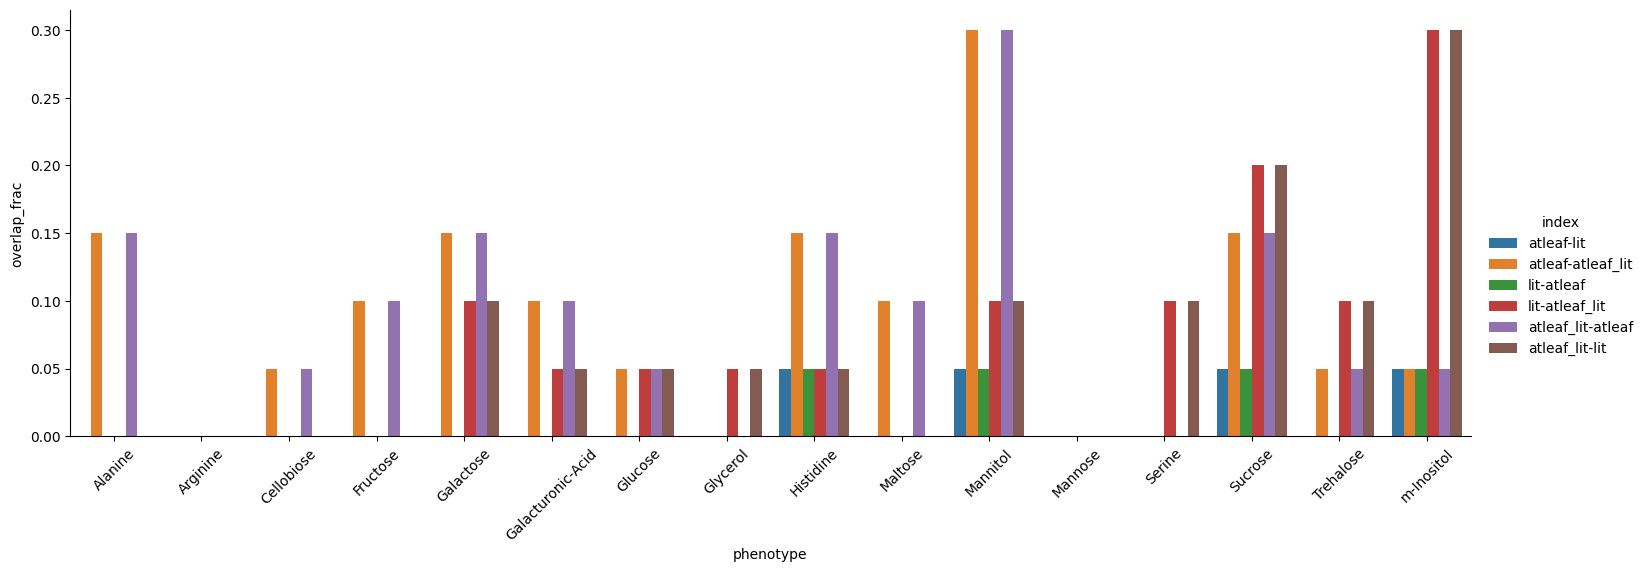

In [111]:
sns.catplot(data=frac_overlap_df, x="phenotype", y="overlap_frac", hue="index", kind="bar", width=0.8, aspect=3)
plt.xticks(rotation=45);